# Chapter 6 Solutions: Quantum Circuits

---

**📘 INSTRUCTOR NOTE:**
- Solutions use the same utilities as the main textbook notebooks
- Students should work through the main chapter notebook first
- Some solutions may still be in development (marked as WIP)

---


In [1]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, MCXGate
from qiskit.quantum_info import Statevector, Operator
# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent ))

from Chapter08_QuantumGates_functions import simulate_measurements,simulate_statevector, plot_measurement_results #type: ignore
print('Solutions setup complete!')

Solutions setup complete!


Counts: {'011': 245, '010': 264, '111': 241, '110': 250}


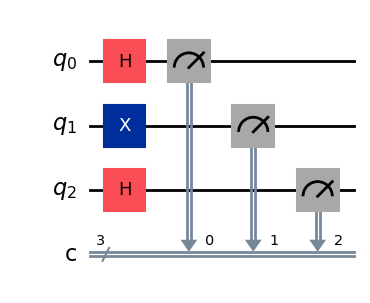

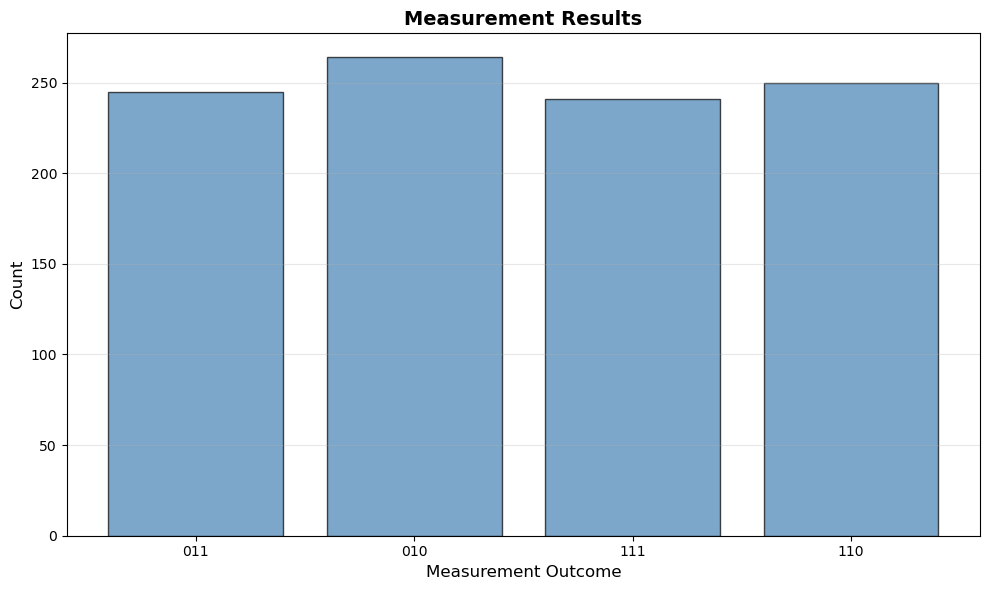

In [2]:
circuit = QuantumCircuit(3, 3)  # type: ignore
circuit.h(0)
circuit.x(1)
circuit.h(2) 
circuit.measure([0,1,2], [0,1,2]) 

counts = simulate_measurements(circuit,1000)# type: ignore
print('Counts:',counts)
plot_measurement_results(counts)# type: ignore
circuit.draw('mpl') 

###  HXY

Counts: {'011': 1000}


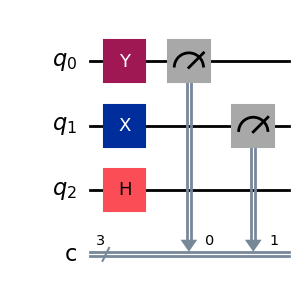

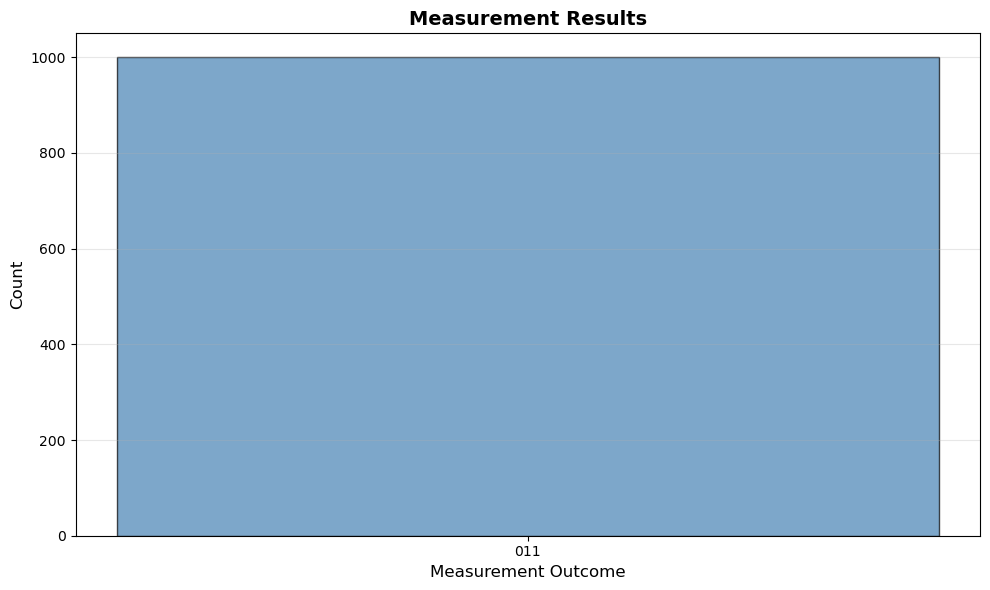

In [3]:
circuit = QuantumCircuit(3, 3)  # type: ignore
circuit.y(0)
circuit.x(1)
circuit.h(2) 
circuit.measure([0,1], [0,1]) 
counts = simulate_measurements(circuit,1000)# type: ignore
print('Counts:',counts)
plot_measurement_results(counts)# type: ignore
circuit.draw('mpl') 

### Bell state using CNOT

Counts: {'01': 506, '10': 494}


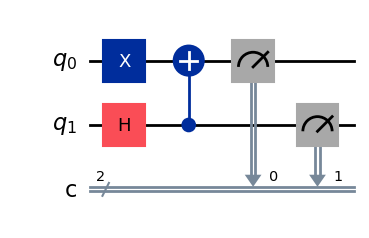

In [4]:
circuit = QuantumCircuit(2, 2) # type: ignore
circuit.x(0) 
circuit.h(1) 
circuit.cx(1,0)
circuit.measure([0,1], [0,1]) 
counts = simulate_measurements(circuit,1000)# type: ignore
print('Counts:',counts)
circuit.draw('mpl')
#plot_histogram(counts)# type: ignore

### Controlled Hadamard and CNOT 

Counts: {'101': 648, '001': 3746, '111': 1873, '100': 622, '110': 1864, '011': 1247}


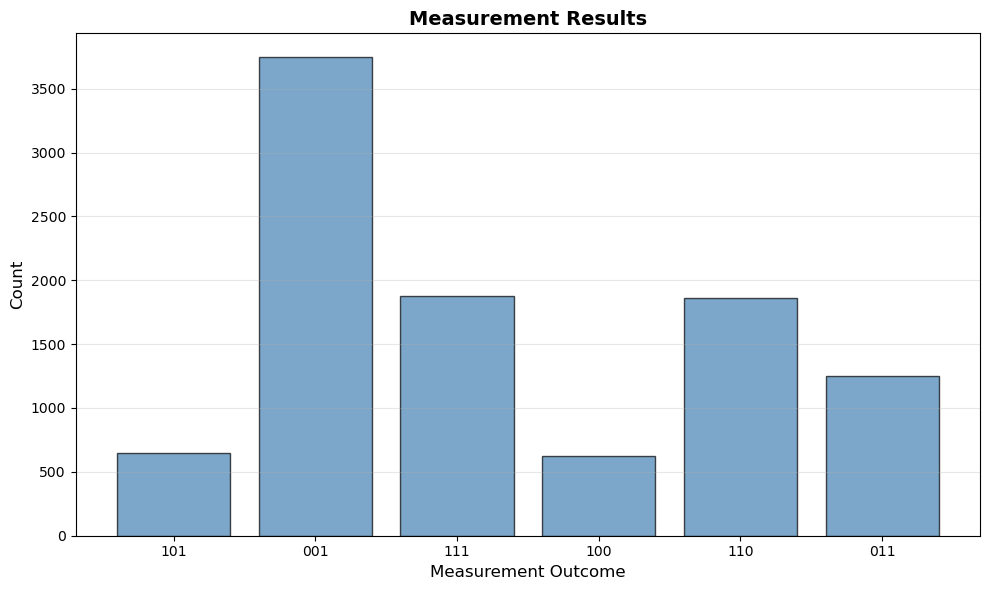

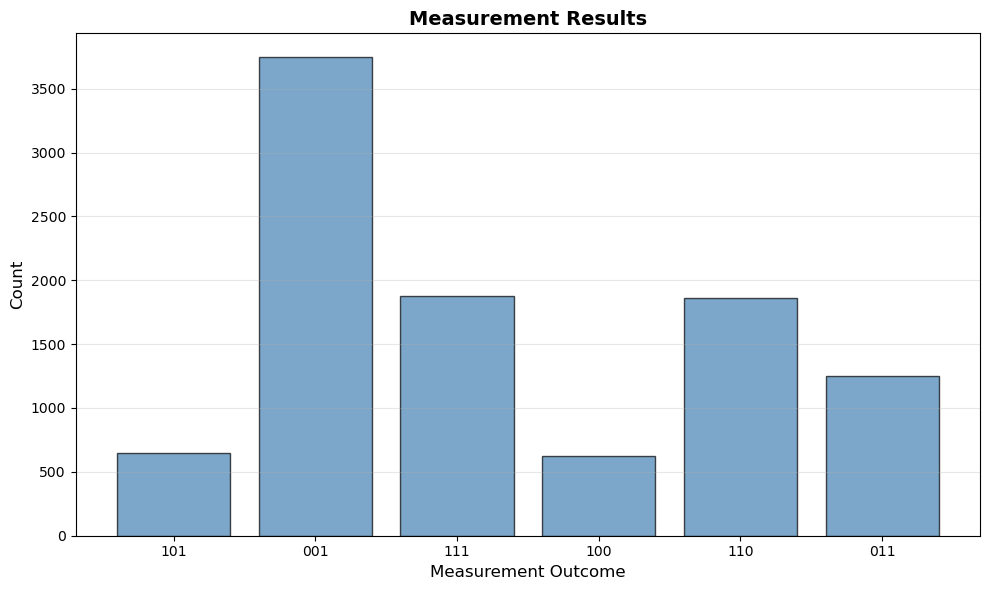

In [5]:
circuit = QuantumCircuit(3, 3) # type: ignore
circuit.y(0) 
circuit.rx(np.pi/3,1) 
circuit.h(2) 
circuit.barrier()
circuit.cx(2,1)
circuit.ch(2,0)
circuit.measure([0,1,2], [0,1,2]) 
counts = simulate_measurements(circuit,10000)# type: ignore
print('Counts:',counts)
circuit.draw('mpl')
plot_measurement_results(counts)# type: ignore
 

### Swap using 3 CNOT gates

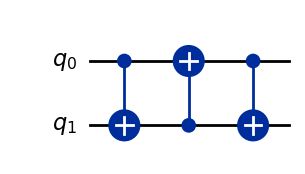

In [6]:
circuit = QuantumCircuit(2) # type: ignore
circuit.cx(0,1)
circuit.cx(1,0)
circuit.cx(0,1)
circuit.draw('mpl')

## 4.9 Additional Exercises

### Bell State

<IPython.core.display.Latex object>

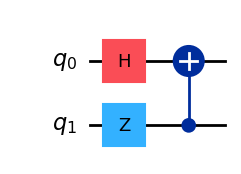

In [7]:
circuit = QuantumCircuit(2)  # type: ignore
circuit.h(0)
circuit.z(1)
circuit.cx(1, 0)
psi = Statevector(circuit)  # type: ignore
display(psi.draw('latex'))
circuit.draw('mpl') 

### Output state exercises

<IPython.core.display.Latex object>

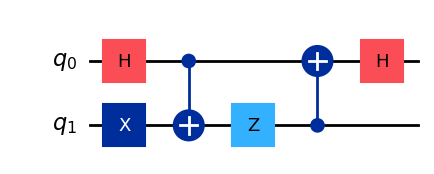

In [8]:
circuit = QuantumCircuit(2)  # type: ignore
circuit.h(0)
circuit.x(1)
circuit.cx(0, 1)
circuit.z(1)
circuit.cx(1, 0)
circuit.h(0)
psi = Statevector(circuit)  # type: ignore
display(psi.draw('latex'))
circuit.draw('mpl') 

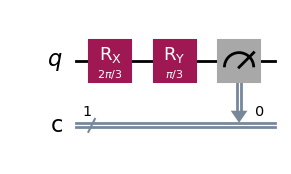

<IPython.core.display.Latex object>

Counts: {'0': 390, '1': 610}


In [10]:
circuit = QuantumCircuit(1, 1)  
theta =  2*np.pi/3
circuit.rx(theta,0)
circuit.ry(np.pi/3,0)
circuit.measure(0, 0) 
display(circuit.draw('mpl')) 
psi = simulate_statevector(circuit)  # type: ignore
display(psi.draw('latex'))
counts = simulate_measurements(circuit,shots = 1000)
print('Counts:',counts)